# Bi-Cross-Validation Evaluation

Evaluate the 5 mSCA models trained via bi-cross-validation on held-out neurons.

**Pipeline per fold:**
1. Load the fold model (trained on `train_idxs` neurons)
2. Infer latents on training neurons 
3. Fit a linear regression from latents → held-out neurons (on half the trials)
4. Evaluate reconstruction R² on the remaining held-out trials


In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import io

# Add workspace root to path so msca is importable
sys.path.insert(0, os.path.abspath("../../.."))
from msca import *
from msca.evaluations import evaluate_trial_average_MLP

# Re-import explicitly after wildcard imports to avoid namespace collisions
from sklearn.model_selection import KFold


## Load Data


In [2]:
def load_data(dir_path, f):
    mat_file = io.loadmat(dir_path + f)
    data_array = mat_file["data"]
    mask = mat_file["mask"]
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()
    return data_array, mask, start_idxs, end_idxs


def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    data_concat = data_downsamp.T
    fr_range = np.ptp(data_concat, axis=1)[:, None]
    data_norm = data_concat / (fr_range + 5)
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]
    fit_data = np.copy(data_snm_norm.T)
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]
    return split_data


# Paths (relative to the notebook directory in experiments/cycling/)
fp = "./data/"


m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(fp, "Cousteau_interp_cycling_m1_rawRates.mat")
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(fp, "Cousteau_interp_cycling_sma_rawRates.mat")

m1_preprocessed = preprocess(m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5)
sma_preprocessed = preprocess(sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5)

X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}

print(f"M1:  {len(m1_preprocessed)} trials, {m1_preprocessed[0].shape[1]} neurons")
print(f"SMA: {len(sma_preprocessed)} trials, {sma_preprocessed[0].shape[1]} neurons")


M1:  20 trials, 116 neurons
SMA: 20 trials, 77 neurons


## Nonlinear Encoder Nonlinear Decoder: Load Saved Neuron Split Indices


In [9]:
experiment_path = "./results/Cousteau/bi-cross-validation-sparsity/no_sparsity/"

train_split_path = os.path.join(experiment_path, "n_train_splits.pt")
test_split_path  = os.path.join(experiment_path, "n_test_splits.pt")

train_idxs = torch.load(train_split_path, weights_only=False)
test_idxs  = torch.load(test_split_path, weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}:  train neurons per fold = {[len(t) for t in train_idxs[k]]}, "
          f"test neurons per fold = {[len(t) for t in test_idxs[k]]}")


Number of folds: 5
  M1:  train neurons per fold = [92, 93, 93, 93, 93], test neurons per fold = [24, 23, 23, 23, 23]
  SMA:  train neurons per fold = [61, 61, 62, 62, 62], test neurons per fold = [16, 16, 15, 15, 15]


## Nonlinear Encoder Nonlinear Decoder: Run Bi-Cross-Validation Evaluation

For each fold `i`:
- Load the model trained on the training neurons of fold `i`
- `X_train`: data subset to the **training neurons** (what the model saw)
- `X_val`: data subset to the **held-out neurons**
- `evaluate_trial_average(msca, X_train, X_val)`: 
  - Infers latents `Z` from `X_train`
  - KFold splits across **trials**: trains a linear regression `Z → X_val` on half the trials, tests on the other half
  - Returns a list of R² values (one per trial split)


In [10]:
all_fold_performances = []   # list of lists: one list of R² per fold

for i in range(n_folds):
    print(f"\n--- Fold {i} ---")

    # Build X_train and X_val for this fold
    X_train = {
        k: [trial[:, train_idxs[k][i]] for trial in v]
        for k, v in X.items()
    }
    X_val = {
        k: [trial[:, test_idxs[k][i]] for trial in v]
        for k, v in X.items()
    }

    # Load the saved mSCA model for fold i 
    model_path = os.path.join(experiment_path, f"msca_split_{i}.pt")
    msca = mSCA(
        n_components=40,
        n_epochs=5000,
        linear=False, # nonlinear encoder 
        loss_func="Gaussian",
        lam_sparse="adaptive", # this is set to 0.05 in simulations -> this is not adaptive 
        lam_orthog=0.1,
        lam_region=0.0,
        decoder_type="nonlinear", # nonlinear decoder
        decoder_hidden_size=40,
        sparsity_warmup_epochs=100,
        decoder_activation="tanh",
        post_hoc_epoch=-1,
        cd_rate=0.5,
        cd_mode="both",
        filter_len=41,
        init="unique",
        decoder_init_mode = "pca",

    )
    msca.load(model_path, X_train)
    print(f"  Loaded: {model_path}")

    # evaluate latents from X_train, predict X_val across trial splits -----
    fold_performances = evaluate_trial_average_MLP(msca, X_train, X_val, n_splits=5)
    all_fold_performances.append(fold_performances)

    mean_r2 = np.mean(fold_performances)
    print(f"  R² (mean over trial splits): {mean_r2:.4f}  |  per split: {[f'{r:.4f}' for r in fold_performances]}")

print("\nDone.")



--- Fold 0 ---
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = adaptive
Using lam_orthog = 23.759950912818965
Using lam_region = 0.0
  Loaded: ./results/Cousteau/bi-cross-validation-sparsity/no_sparsity/msca_split_0.pt
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  R² (mean over trial splits): 0.7969  |  per split: ['0.7907', '0.7705', '0.8273', '0.7882', '0.8081']

--- Fold 1 ---
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = adaptive
Using lam_orthog = 24.620536978894616
Using lam_region = 0.0
  Loaded: ./results/Cousteau/bi-cross-validation-sparsity/no_sparsity/msca_split_1.pt
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  R² (mean over trial splits): 0.8020  |  per split: ['0.7878', '0.7769', '0.8306', '0.8031', '0.8114']

--- Fold 2 ---
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse 

[2026-06-24 21:10:55,151] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-06-24 21:10:55,151] torch._dynamo.convert_frame: [WARNING]    function: '_gaussian_filter' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:72)
[2026-06-24 21:10:55,151] torch._dynamo.convert_frame: [WARNING]    last reason: ___guarded_code.valid
[2026-06-24 21:10:55,151] torch._dynamo.convert_frame: [WARNING] To log all recompilation reasons, use TORCH_LOGS="recompiles".
[2026-06-24 21:10:55,151] torch._dynamo.convert_frame: [WARNING] To diagnose recompilation issues, see https://pytorch.org/docs/master/compile/troubleshooting.html.


  R² (mean over trial splits): 0.8021  |  per split: ['0.7930', '0.7729', '0.8332', '0.7856', '0.8260']

--- Fold 3 ---
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = adaptive
Using lam_orthog = 23.909526854389323
Using lam_region = 0.0
  Loaded: ./results/Cousteau/bi-cross-validation-sparsity/no_sparsity/msca_split_3.pt
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  R² (mean over trial splits): 0.7918  |  per split: ['0.7805', '0.7606', '0.8189', '0.7941', '0.8049']

--- Fold 4 ---
Using region-weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}
Using lam_sparse = adaptive
Using lam_orthog = 24.180857446589997
Using lam_region = 0.0
  Loaded: ./results/Cousteau/bi-cross-validation-sparsity/no_sparsity/msca_split_4.pt
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155
  R² (mean over trial splits): 0.7463  |  per split: ['0.7311', '0.7099', '0.7806', '0.7428', '0.7672']

Done.


## Nonlinear Encoder Nonlinear Decoder: Summarise and Plot Results


5
Per neuron-fold mean R²:
  Fold 0: 0.7969
  Fold 1: 0.8020
  Fold 2: 0.8021
  Fold 3: 0.7918
  Fold 4: 0.7463

Overall  mean ± std: 0.7878 ± 0.0301


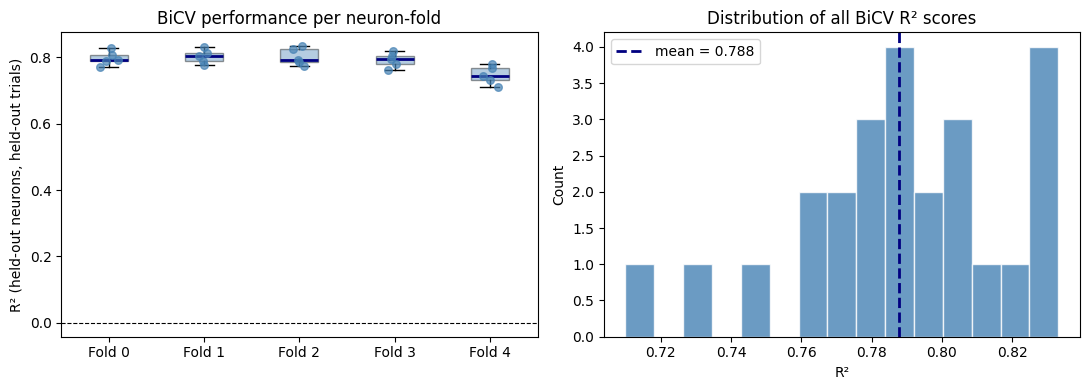

In [11]:

fold_means = [np.mean(p) for p in all_fold_performances]   # mean per neuron-fold
all_r2s = np.concatenate(all_fold_performances)            # all individual R² values

print(len(all_fold_performances))
print("Per neuron-fold mean R²:")
for i, m in enumerate(fold_means):
    print(f"  Fold {i}: {m:.4f}")
print(f"\nOverall  mean ± std: {np.mean(all_r2s):.4f} ± {np.std(all_r2s):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(11, 4))


axes[0].boxplot(
    all_fold_performances,
    positions=np.arange(n_folds),
    widths=0.4,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.4),
    medianprops=dict(color="navy", linewidth=2),
    showfliers=False,
)
for i, perfs in enumerate(all_fold_performances):
    axes[0].scatter(
        np.full(len(perfs), i) + np.random.uniform(-0.1, 0.1, len(perfs)),
        perfs, color="steelblue", alpha=0.7, s=30, zorder=3
    )
axes[0].set_xticks(np.arange(n_folds))
axes[0].set_xticklabels([f"Fold {i}" for i in range(n_folds)])
axes[0].set_ylabel("R² (held-out neurons, held-out trials)")
axes[0].set_title("BiCV performance per neuron-fold")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")


axes[1].hist(all_r2s, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(np.mean(all_r2s), color="navy", linewidth=2, linestyle="--",
               label=f"mean = {np.mean(all_r2s):.3f}")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of all BiCV R² scores")
axes[1].legend()

plt.tight_layout()

plt.show()


## Nonlinear Encoder Linear Decoder Evaluation

Number of folds: 5
  M1:  train neurons per fold = [92, 93, 93, 93, 93], test neurons per fold = [24, 23, 23, 23, 23]
  SMA:  train neurons per fold = [61, 61, 62, 62, 62], test neurons per fold = [16, 16, 15, 15, 15]

--- Fold 0 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 23.759950912818965
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 23.759950912818965
  lam_region  = 0.0
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
  Loaded: ./nonlinear-linear-5000-BiCV/msca_0.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.7566  |  per split: ['0.7454', '0.7145', '0.7895', '0.7526', '0.7807']

--- Fold 1 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 24.620536978894616
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.09067048718693743
  lam_orthog  = 24.620536978894616
  lam_region  = 0.0
  region_weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
  Loaded: ./nonlinear-linear-5000-BiCV/msca_1.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.7704  |  per split: ['0.7567', '0.7358', '0.7981', '0.7662', '0.7950']

--- Fold 2 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 0.08719028411721379
Using lam_orthog = 23.97254373430498
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08719028411721379
  lam_orthog  = 23.97254373430498
  lam_region  = 0.0
  region_weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
  Loaded: ./nonlinear-linear-5000-BiCV/msca_2.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)
/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)
[2026-05-07 14:50:44,392] torch._dynamo.convert_frame: [WARNING] torch._dynamo hit config.cache_size_limit (8)
[2026-05-07 14:50:44,392] torch._dynamo.convert_frame: [WARNING]    function: '_gaussian_filter' (/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/filters.py:72)
[2026-05-07 

  R² (mean over trial splits): 0.7741  |  per split: ['0.7746', '0.7539', '0.8002', '0.7396', '0.8023']

--- Fold 3 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 0.08776341774532091
Using lam_orthog = 23.909526854389323
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08776341774532091
  lam_orthog  = 23.909526854389323
  lam_region  = 0.0
  region_weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
  Loaded: ./nonlinear-linear-5000-BiCV/msca_3.pt
  R² (mean over trial splits): 0.7604  |  per split: ['0.7527', '0.7253', '0.7850', '0.7665', '0.7726']

--- Fold 4 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}
Using lam_sparse = 0.086642

/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.7143  |  per split: ['0.6924', '0.6818', '0.7540', '0.6939', '0.7495']

Done.
5
Per neuron-fold mean R²:
  Fold 0: 0.7566
  Fold 1: 0.7704
  Fold 2: 0.7741
  Fold 3: 0.7604
  Fold 4: 0.7143

Overall  mean ± std: 0.7552 ± 0.0333


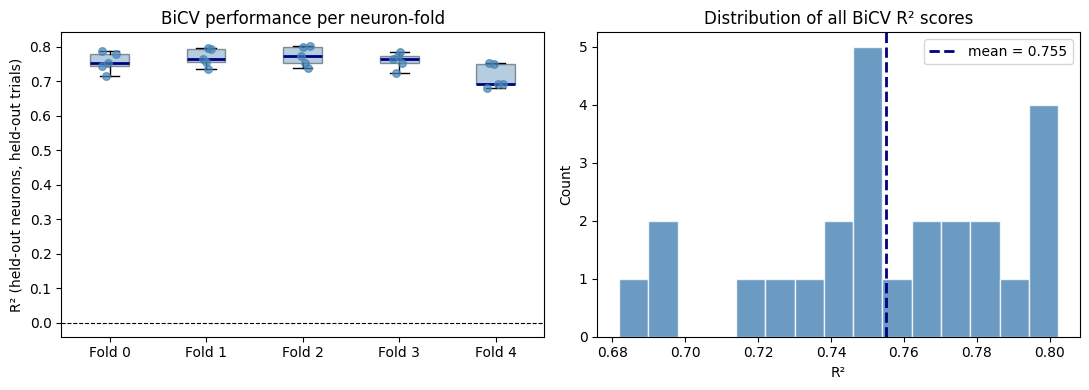

In [ ]:
experiment_path = "./nonlinear-linear-5000-BiCV"

train_split_path = os.path.join(experiment_path, "n_train_splits.pt")
test_split_path  = os.path.join(experiment_path, "n_test_splits.pt")

train_idxs = torch.load(train_split_path, weights_only=False)
test_idxs  = torch.load(test_split_path, weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}:  train neurons per fold = {[len(t) for t in train_idxs[k]]}, "
          f"test neurons per fold = {[len(t) for t in test_idxs[k]]}")
    


all_fold_performances = []   #  one list of R² per fold

for i in range(n_folds):
    print(f"\n--- Fold {i} ---")

  
    X_train = {
        k: [trial[:, train_idxs[k][i]] for trial in v]
        for k, v in X.items()
    }
    X_val = {
        k: [trial[:, test_idxs[k][i]] for trial in v]
        for k, v in X.items()
    }


    model_path = os.path.join(experiment_path, f"msca_{i}.pt")
    msca_model = mSCA(
        n_components=40,
        linear=False,
        loss_func="Gaussian",
        lam_sparse=2.5,
        lam_region=0.0,
        lam_orthog=0.1,
        decoder_type="linear",
        decoder_hidden_size=40,
        decoder_activation="GeLU",
        post_hoc_epoch=-1,
        cd_rate=0.5,
        cd_mode="both",
        filter_len=41,
        init="unique",
        decoder_init_mode="pca",
    )
    msca_model.load(model_path, X_train)
    print(f"  Loaded: {model_path}")

    fold_performances = evaluate_trial_average_MLP(msca_model, X_train, X_val, n_splits=5)
    all_fold_performances.append(fold_performances)

    mean_r2 = np.mean(fold_performances)
    print(f"  R² (mean over trial splits): {mean_r2:.4f}  |  per split: {[f'{r:.4f}' for r in fold_performances]}")

print("\nDone.")



# =============================== #


fold_means = [np.mean(p) for p in all_fold_performances]   # mean per neuron-fold
all_r2s = np.concatenate(all_fold_performances)            # all individual R² values

print(len(all_fold_performances))
print("Per neuron-fold mean R²:")
for i, m in enumerate(fold_means):
    print(f"  Fold {i}: {m:.4f}")
print(f"\nOverall  mean ± std: {np.mean(all_r2s):.4f} ± {np.std(all_r2s):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))


axes[0].boxplot(
    all_fold_performances,
    positions=np.arange(n_folds),
    widths=0.4,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.4),
    medianprops=dict(color="navy", linewidth=2),
    showfliers=False,
)
for i, perfs in enumerate(all_fold_performances):
    axes[0].scatter(
        np.full(len(perfs), i) + np.random.uniform(-0.1, 0.1, len(perfs)),
        perfs, color="steelblue", alpha=0.7, s=30, zorder=3
    )
axes[0].set_xticks(np.arange(n_folds))
axes[0].set_xticklabels([f"Fold {i}" for i in range(n_folds)])
axes[0].set_ylabel("R² (held-out neurons, held-out trials)")
axes[0].set_title("BiCV performance per neuron-fold")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")


axes[1].hist(all_r2s, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(np.mean(all_r2s), color="navy", linewidth=2, linestyle="--",
               label=f"mean = {np.mean(all_r2s):.3f}")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of all BiCV R² scores")
axes[1].legend()

plt.tight_layout()
plt.show()



# Linear Encoder Linear Decoder Evaluation 

Number of folds: 5
  M1:  train neurons per fold = [92, 93, 93, 93, 93], test neurons per fold = [24, 23, 23, 23, 23]
  SMA:  train neurons per fold = [61, 61, 62, 62, 62], test neurons per fold = [16, 16, 15, 15, 15]

--- Fold 0 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
Using lam_sparse = 0.08812463819255682
Using lam_orthog = 23.759950912818965
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08812463819255682
  lam_orthog  = 23.759950912818965
  lam_region  = 0.0
  region_weights = {'M1': 0.7975064363288057, 'SMA': 1.3403179544112407}
  Loaded: ./linear-linear-5000-BiCV/msca_0.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.7405  |  per split: ['0.7204', '0.7057', '0.7761', '0.7547', '0.7458']

--- Fold 1 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
Using lam_sparse = 0.09067048718693743
Using lam_orthog = 24.620536978894616
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.09067048718693743
  lam_orthog  = 24.620536978894616
  lam_region  = 0.0
  region_weights = {'M1': 0.7748147412125208, 'SMA': 1.4097037476845866}
  Loaded: ./linear-linear-5000-BiCV/msca_1.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.7383  |  per split: ['0.7155', '0.7066', '0.7682', '0.7445', '0.7568']

--- Fold 2 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
Using lam_sparse = 0.08719028411721379
Using lam_orthog = 23.97254373430498
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08719028411721379
  lam_orthog  = 23.97254373430498
  lam_region  = 0.0
  region_weights = {'M1': 0.7918909087294841, 'SMA': 1.3564843663277388}
  Loaded: ./linear-linear-5000-BiCV/msca_2.pt


...

  R² (mean over trial splits): 0.7390  |  per split: ['0.7201', '0.7269', '0.7803', '0.7091', '0.7585']

--- Fold 3 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
Using lam_sparse = 0.08776341774532091
Using lam_orthog = 23.909526854389323
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08776341774532091
  lam_orthog  = 23.909526854389323
  lam_region  = 0.0
  region_weights = {'M1': 0.7823761702463815, 'SMA': 1.3853438297639196}
  Loaded: ./linear-linear-5000-BiCV/msca_3.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.7434  |  per split: ['0.7321', '0.7202', '0.7679', '0.7524', '0.7447']

--- Fold 4 ---
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.1, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.1
Using region-weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}
Using lam_sparse = 0.08664245755343558
Using lam_orthog = 24.180857446589997
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.08664245755343558
  lam_orthog  = 24.180857446589997
  lam_region  = 0.0
  region_weights = {'M1': 0.813251157638652, 'SMA': 1.2980816475972463}
  Loaded: ./linear-linear-5000-BiCV/msca_4.pt


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


  R² (mean over trial splits): 0.6952  |  per split: ['0.6662', '0.6755', '0.7271', '0.6953', '0.7117']

Done.
5
Per neuron-fold mean R²:
  Fold 0: 0.7405
  Fold 1: 0.7383
  Fold 2: 0.7390
  Fold 3: 0.7434
  Fold 4: 0.6952

Overall  mean ± std: 0.7313 ± 0.0293


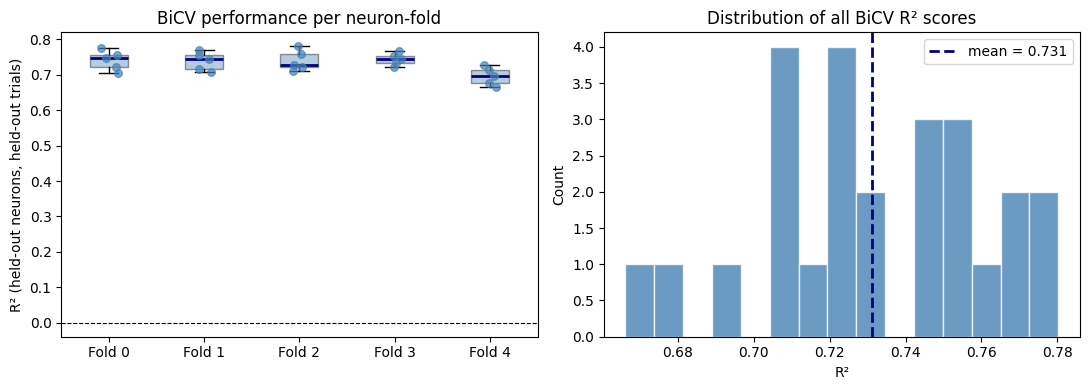

In [ ]:
experiment_path = "./linear-linear-5000-BiCV"

train_split_path = os.path.join(experiment_path, "n_train_splits.pt")
test_split_path  = os.path.join(experiment_path, "n_test_splits.pt")

train_idxs = torch.load(train_split_path, weights_only=False)
test_idxs  = torch.load(test_split_path, weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}:  train neurons per fold = {[len(t) for t in train_idxs[k]]}, "
          f"test neurons per fold = {[len(t) for t in test_idxs[k]]}")
    


all_fold_performances = []  

for i in range(n_folds):
    print(f"\n--- Fold {i} ---")

    X_train = {
        k: [trial[:, train_idxs[k][i]] for trial in v]
        for k, v in X.items()
    }
    X_val = {
        k: [trial[:, test_idxs[k][i]] for trial in v]
        for k, v in X.items()
    }


    model_path = os.path.join(experiment_path, f"msca_{i}.pt")
    msca_model = mSCA(
        n_components=40,
        linear=True,
        loss_func="Gaussian",
        lam_sparse=2.5,
        lam_region=0.0,
        lam_orthog=0.1,
        decoder_type="linear",
        decoder_hidden_size=40,
        decoder_activation="GeLU",
        post_hoc_epoch=-1,
        cd_rate=0.5,
        cd_mode="both",
        filter_len=41,
        init="unique",
        decoder_init_mode="pca",
    )
    msca_model.load(model_path, X_train)
    print(f"  Loaded: {model_path}")


    fold_performances = evaluate_trial_average_MLP(msca_model, X_train, X_val, n_splits=5)
    all_fold_performances.append(fold_performances)

    mean_r2 = np.mean(fold_performances)
    print(f"  R² (mean over trial splits): {mean_r2:.4f}  |  per split: {[f'{r:.4f}' for r in fold_performances]}")

print("\nDone.")




# one R² per (neuron-fold, trial-fold) combination
fold_means = [np.mean(p) for p in all_fold_performances]   # mean per neuron-fold
all_r2s = np.concatenate(all_fold_performances)            # all individual R² values

print(len(all_fold_performances))
print("Per neuron-fold mean R²:")
for i, m in enumerate(fold_means):
    print(f"  Fold {i}: {m:.4f}")
print(f"\nOverall  mean ± std: {np.mean(all_r2s):.4f} ± {np.std(all_r2s):.4f}")


fig, axes = plt.subplots(1, 2, figsize=(11, 4))


axes[0].boxplot(
    all_fold_performances,
    positions=np.arange(n_folds),
    widths=0.4,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.4),
    medianprops=dict(color="navy", linewidth=2),
    showfliers=False,
)
for i, perfs in enumerate(all_fold_performances):
    axes[0].scatter(
        np.full(len(perfs), i) + np.random.uniform(-0.1, 0.1, len(perfs)),
        perfs, color="steelblue", alpha=0.7, s=30, zorder=3
    )
axes[0].set_xticks(np.arange(n_folds))
axes[0].set_xticklabels([f"Fold {i}" for i in range(n_folds)])
axes[0].set_ylabel("R² (held-out neurons, held-out trials)")
axes[0].set_title("BiCV performance per neuron-fold")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")


axes[1].hist(all_r2s, bins=15, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(np.mean(all_r2s), color="navy", linewidth=2, linestyle="--",
               label=f"mean = {np.mean(all_r2s):.3f}")
axes[1].set_xlabel("R²")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of all BiCV R² scores")
axes[1].legend()

plt.tight_layout()
plt.show()

